In [13]:
import pandas as pd 
import os 

file_path = '/Users/swaritpakala/Downloads/test.csv'
data = pd.read_csv(file_path)
print(data.head(10))
print(data.shape)
print(data.dtypes)



     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   
5  1466          60       RL         75.0    10000   Pave   NaN      IR1   
6  1467          20       RL          NaN     7980   Pave   NaN      IR1   
7  1468          60       RL         63.0     8402   Pave   NaN      IR1   
8  1469          20       RL         85.0    10176   Pave   NaN      Reg   
9  1470          20       RL         70.0     8400   Pave   NaN      Reg   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1    

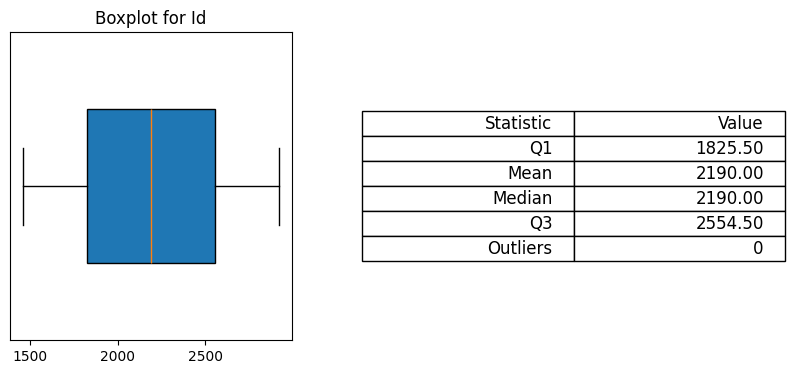

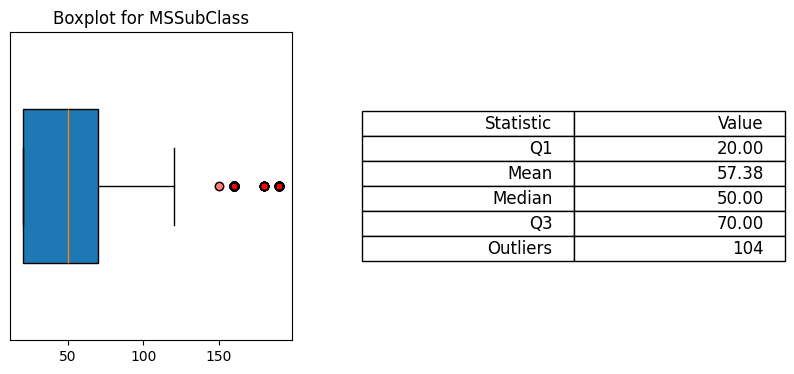

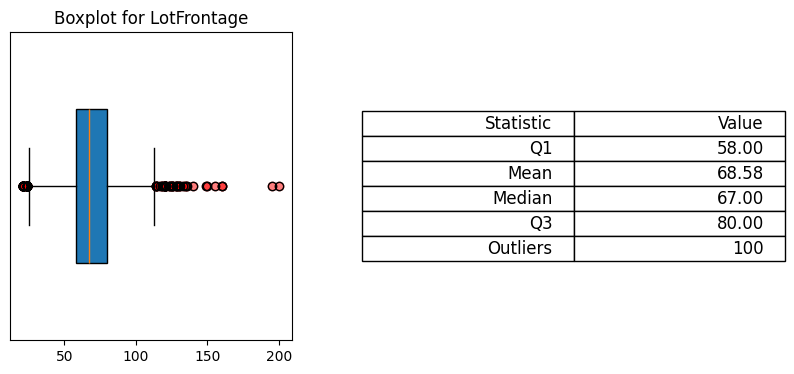

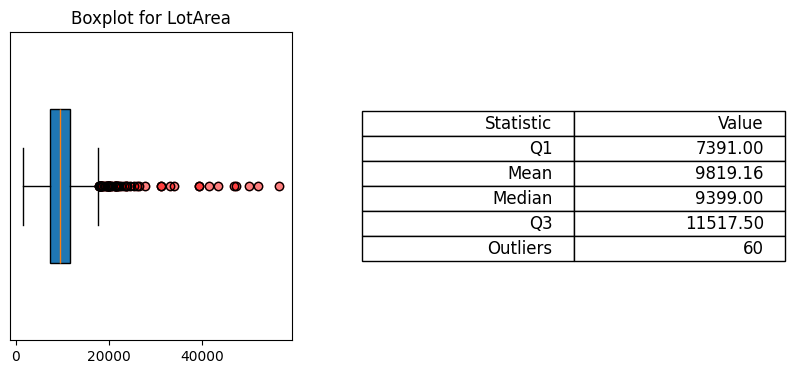

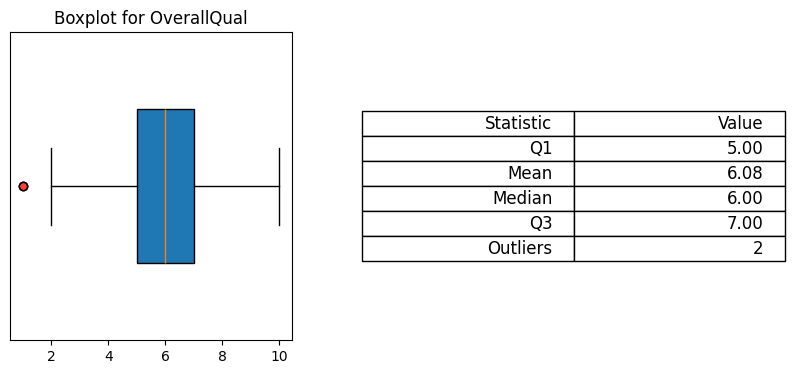

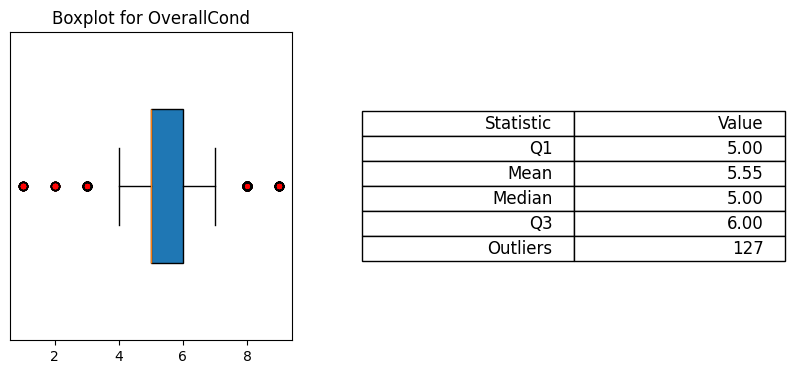

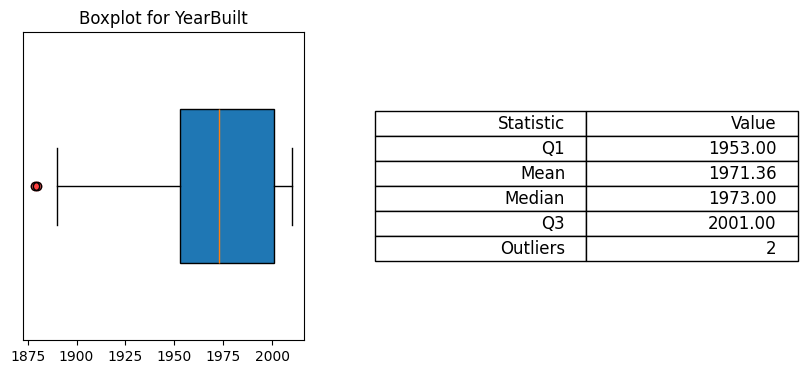

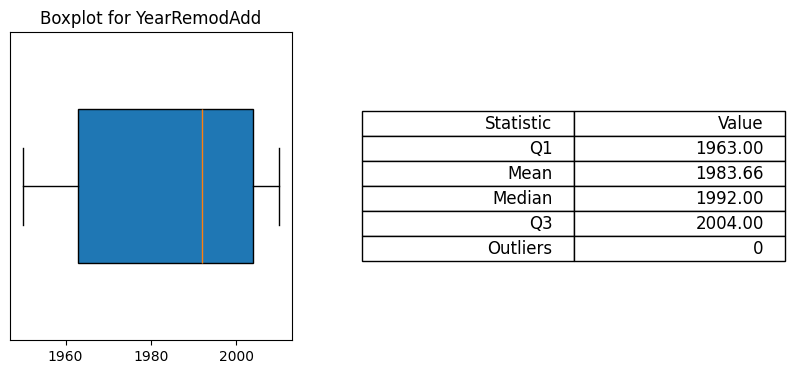

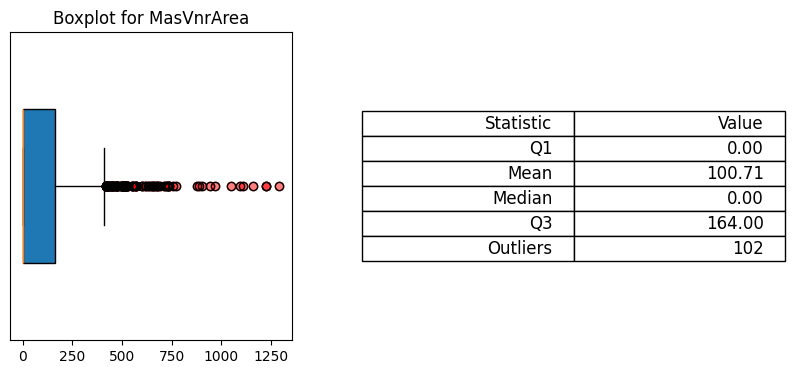

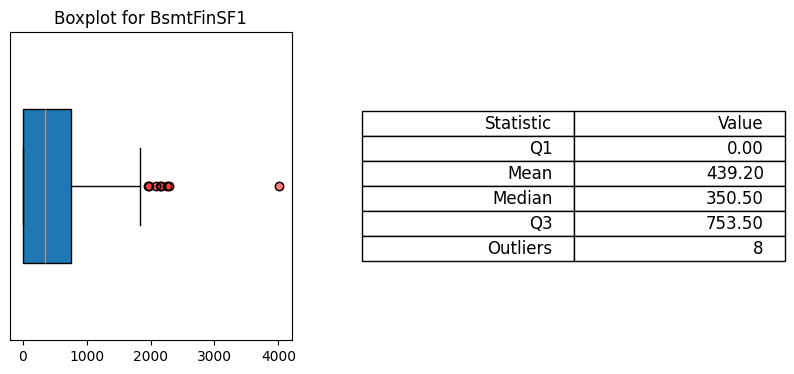

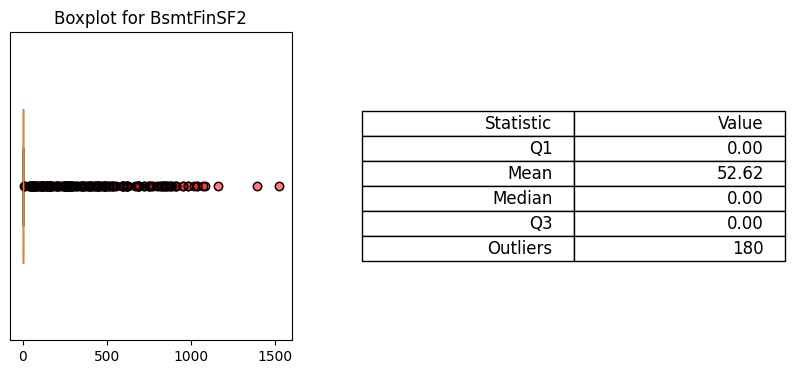

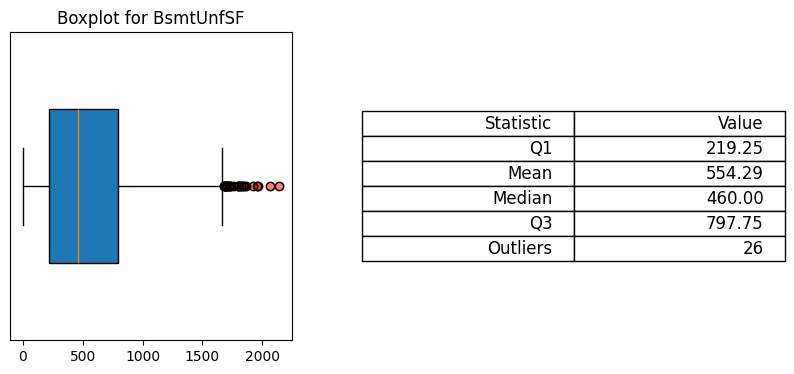

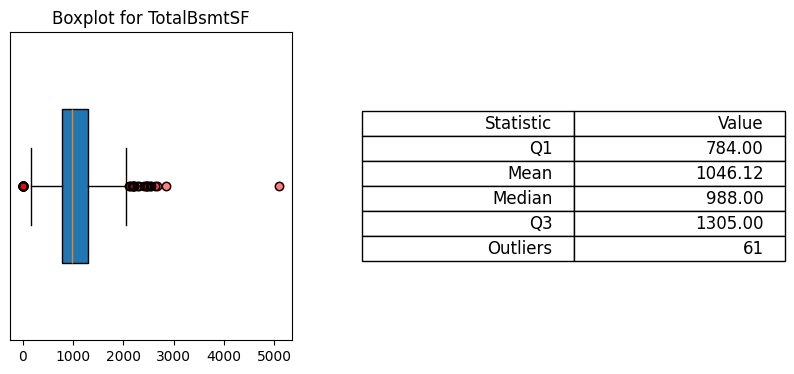

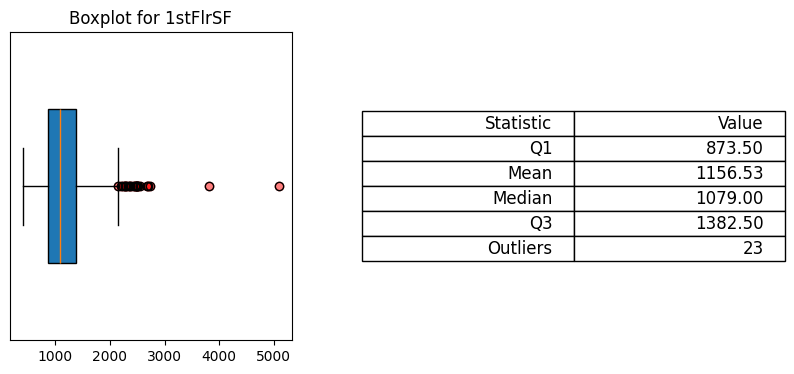

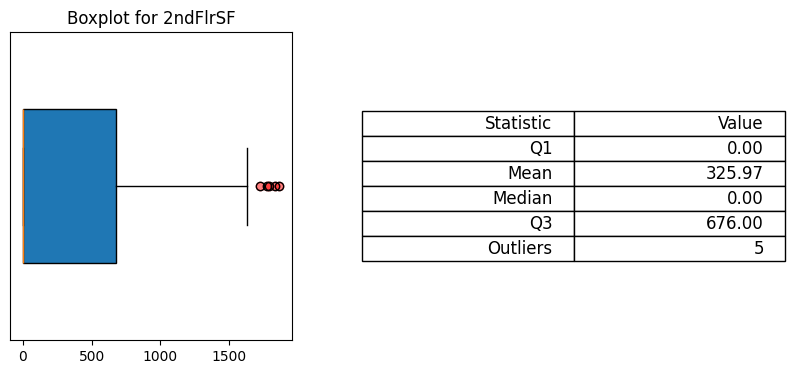

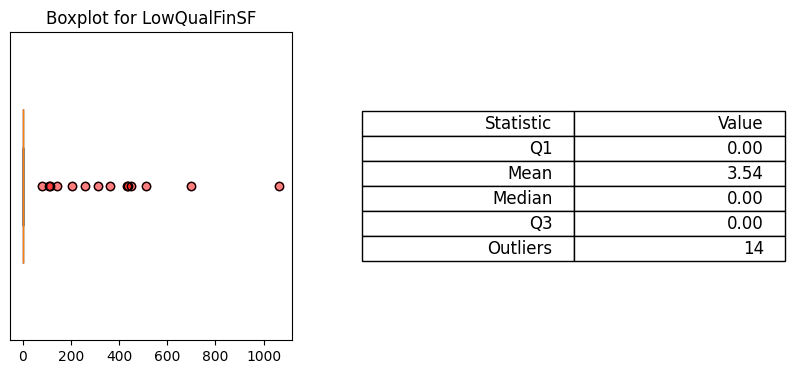

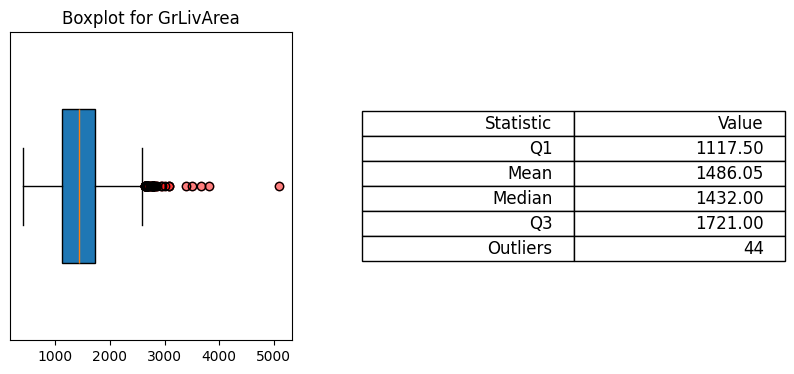

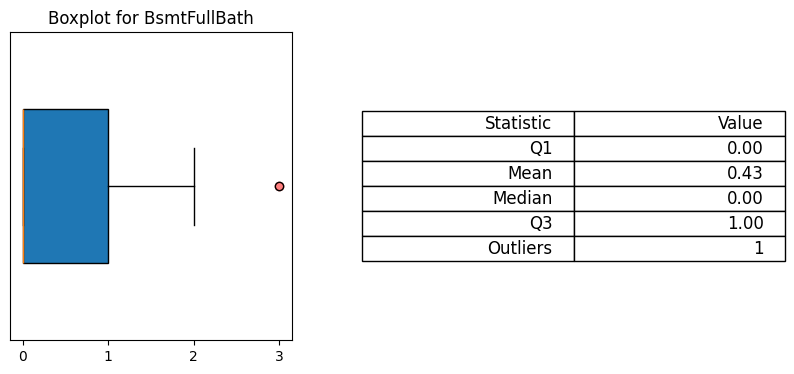

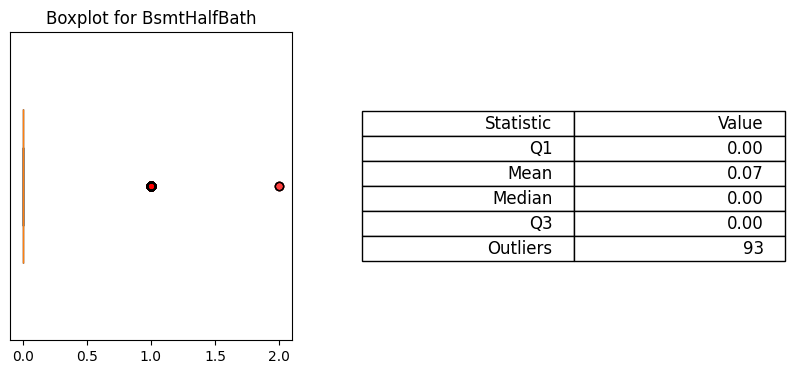

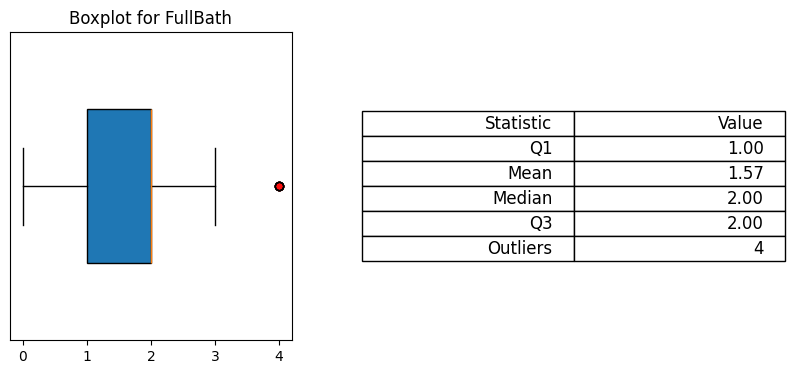

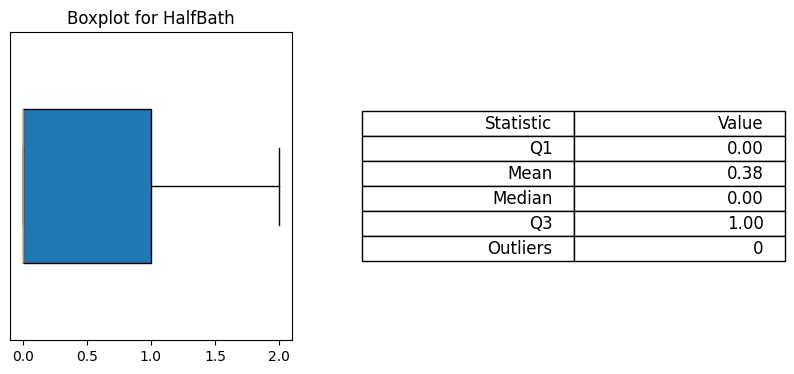

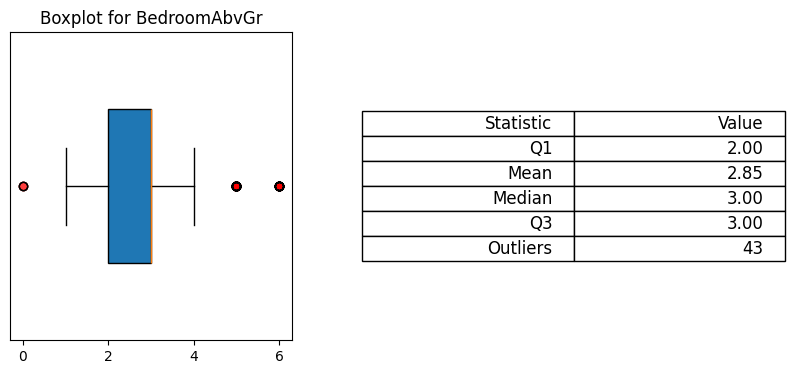

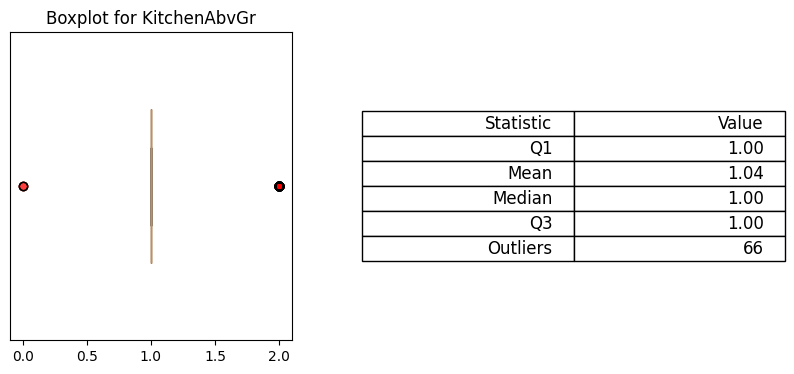

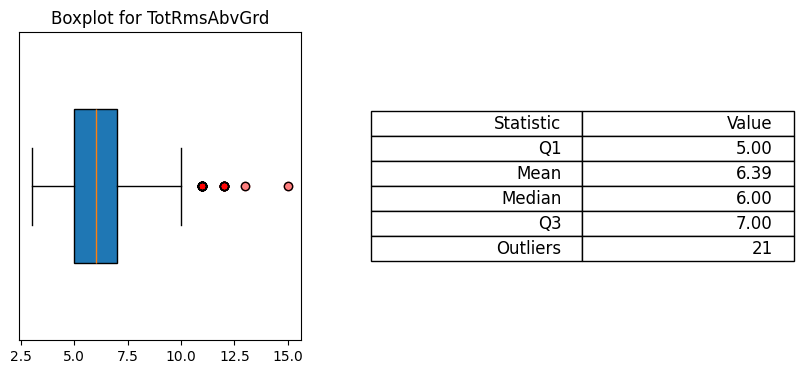

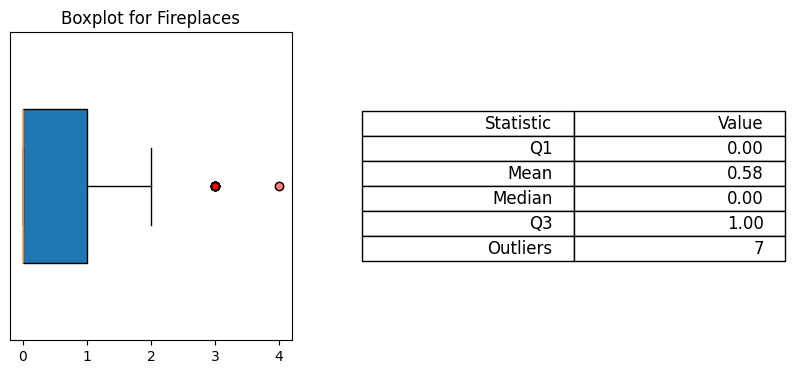

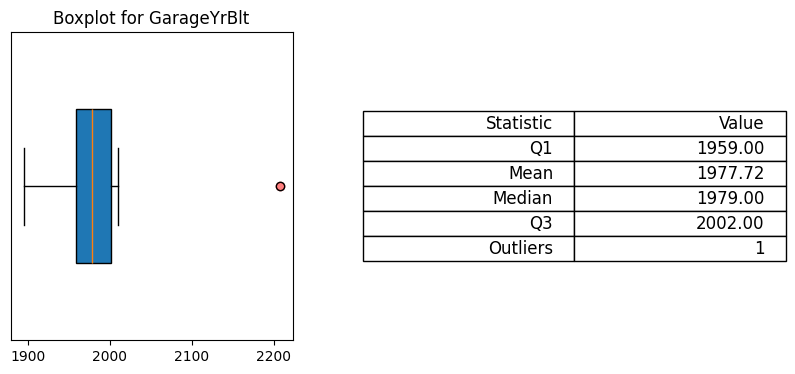

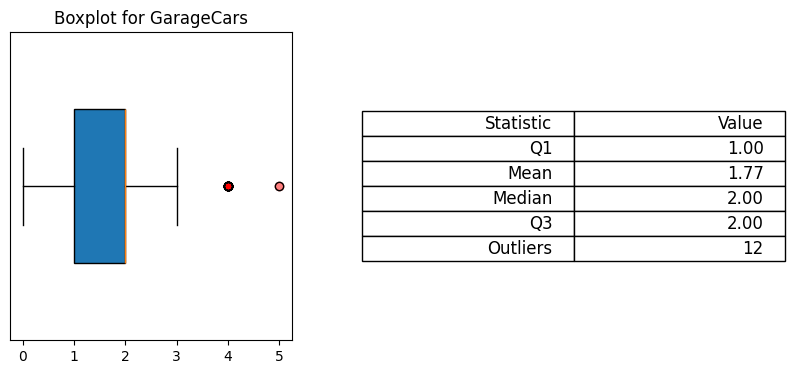

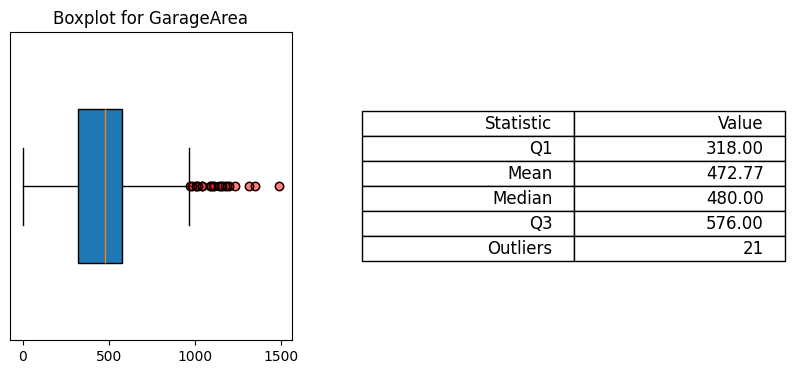

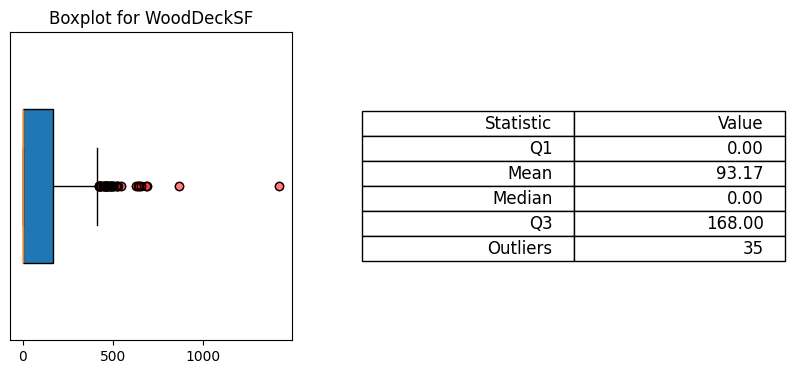

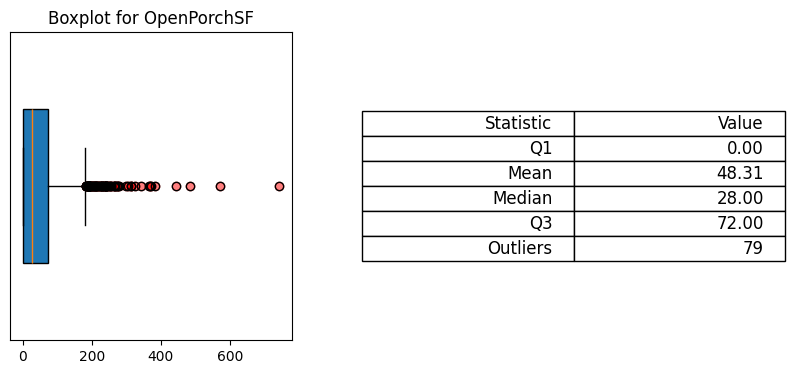

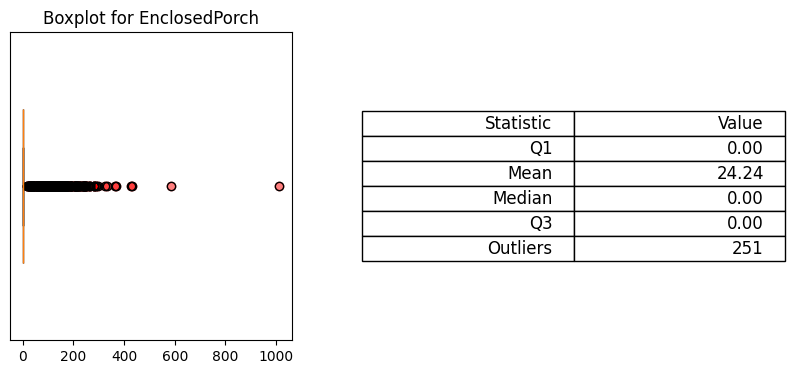

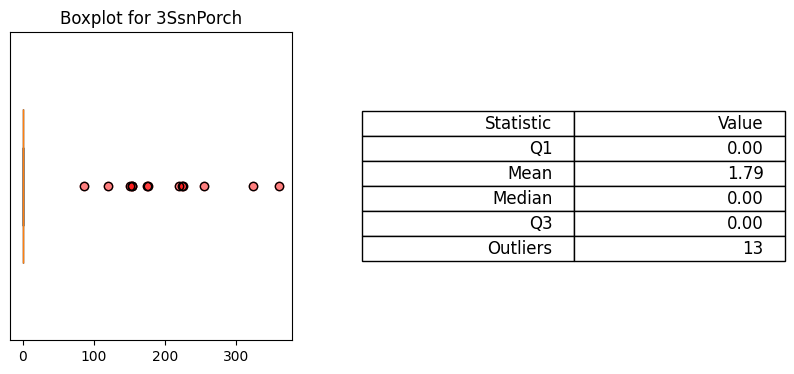

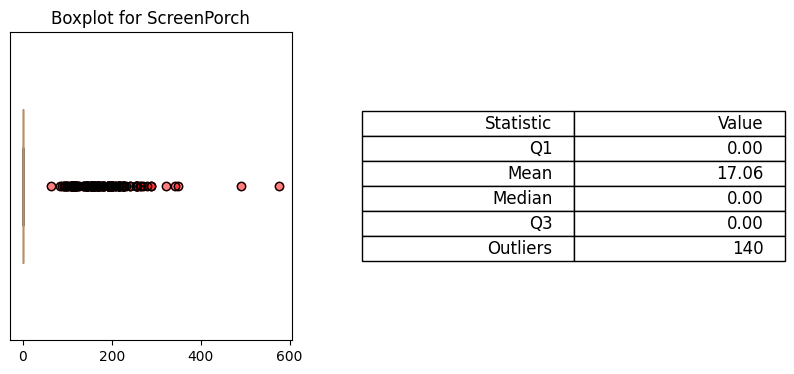

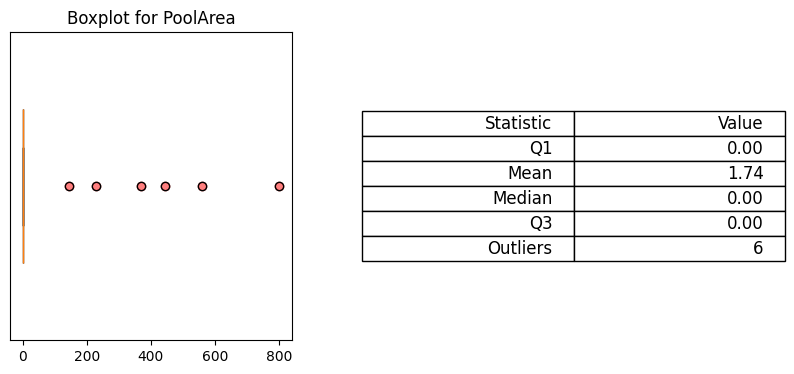

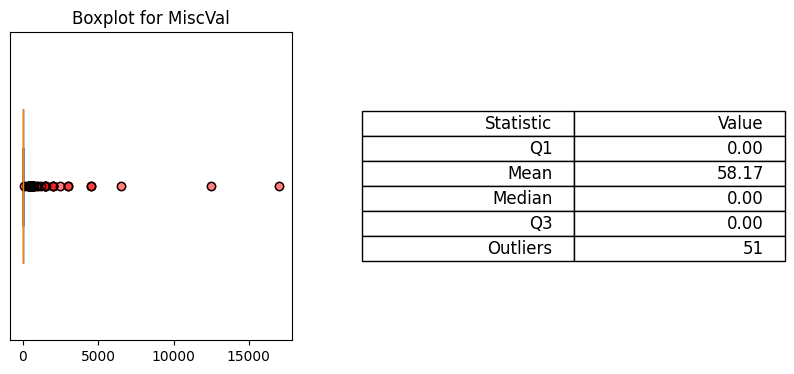

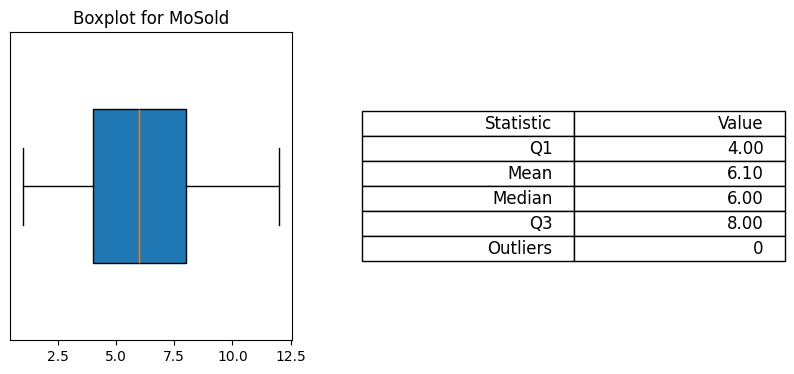

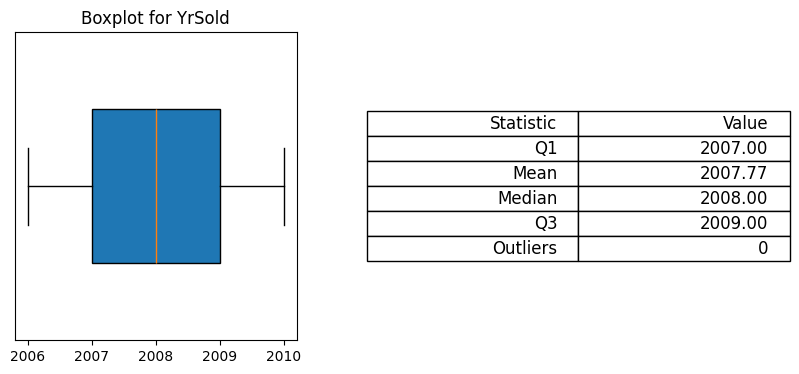

In [67]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
file_path = '/Users/swaritpakala/Downloads/test.csv'
data = pd.read_csv(file_path)

# Remove leading and trailing spaces from all column names
data.columns = data.columns.str.strip()

# Loop through columns and create boxplots
for column_name in data.columns:
    # Check if the column has numerical data
    if pd.api.types.is_numeric_dtype(data[column_name]):
        # Remove rows with empty or NaN values
        clean_data = data.dropna(subset=[column_name])

        # Create a figure and axes for the boxplot and key table
        fig, (ax_box, ax_table) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.5]})

        # Create a boxplot for the specified column
        bp = ax_box.boxplot(clean_data[column_name], vert=False, widths=0.5, patch_artist=True)

        # Calculate statistics
        q1 = clean_data[column_name].quantile(0.25)
        mean = clean_data[column_name].mean()
        median = clean_data[column_name].median()
        q3 = clean_data[column_name].quantile(0.75)

        # Identify outliers
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = clean_data[(clean_data[column_name] < lower_bound) | (clean_data[column_name] > upper_bound)]
        num_outliers = len(outliers)

        # Create a table with key statistics and number of outliers
        stats_table_data = [
            ["Statistic", "Value"],
            ["Q1", f'{q1:.2f}'],
            ["Mean", f'{mean:.2f}'],
            ["Median", f'{median:.2f}'],
            ["Q3", f'{q3:.2f}'],
            ["Outliers", f'{num_outliers}']
        ]

        # Create the table with cellText and colLabels
        stats_table = ax_table.table(cellText=stats_table_data, loc='center')
        stats_table.auto_set_font_size(False)
        stats_table.set_fontsize(12)

        # Adjust the appearance of the table
        stats_table.scale(1, 1.5)
        ax_table.axis('off')  # Hide the table axes

        # Display outliers as red dots on the boxplot
        outlier_values = outliers[column_name].values
        ax_box.scatter(outlier_values, np.repeat(1, len(outlier_values)), color='red', marker='o', alpha=0.5)

        ax_box.set_title(f'Boxplot for {column_name}')
        ax_box.set_yticks([])  # Remove the y-axis

        plt.show()


In [41]:
import pandas as pd

# Load your data into a DataFrame
# Assuming you have loaded your data into a DataFrame named "data"
file_path = '/Users/swaritpakala/Downloads/test.csv'
data = pd.read_csv(file_path)

# Define a threshold for the majority (e.g., 75% of values should be zeros)
threshold = 0.75  # Adjust as needed

# Calculate the ratio of zero values to the total number of rows for each column
zero_ratio = (data == 0).mean()

# Identify columns where the zero ratio exceeds the threshold
columns_to_remove = zero_ratio[zero_ratio > threshold].index

# Remove the identified columns from the DataFrame
data = data.drop(columns=columns_to_remove)

# Save the modified DataFrame to a CSV file
data.to_csv('/Users/swaritpakala/Downloads/modified_data.csv', index=False)

# Print the names of the removed columns
print("Removed Columns:", columns_to_remove)
print(data)


Removed Columns: Index(['BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 'EnclosedPorch',
       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype='object')
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0     1461          20       RH         80.0    11622   Pave   NaN      Reg   
1     1462          20       RL         81.0    14267   Pave   NaN      IR1   
2     1463          60       RL         74.0    13830   Pave   NaN      IR1   
3     1464          60       RL         78.0     9978   Pave   NaN      IR1   
4     1465         120       RL         43.0     5005   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1454  2915         160       RM         21.0     1936   Pave   NaN      Reg   
1455  2916         160       RM         21.0     1894   Pave   NaN      Reg   
1456  2917          20       RL        160.0    20000   Pave   NaN      Reg   
1457  2918          85       RL         62

In [6]:
import pandas as pd 

file_path = '/Users/swaritpakala/Downloads/modified_data.csv'
data = pd.read_csv(file_path)

missing_percentage = data.isnull().mean() * 100

# Select columns where the missing percentage is greater than 75
columns_with_high_missing_percentage = missing_percentage[missing_percentage > 75].index

# Display the columns
print("Columns with more than 75% missing values:")
print(columns_with_high_missing_percentage)

data = data.drop(columns=columns_with_high_missing_percentage)
print(data)
data.to_csv('/Users/swaritpakala/documents/cleaned_data.csv', index=False)



Columns with more than 75% missing values:
Index(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape  \
0     1461          20       RH         80.0    11622   Pave      Reg   
1     1462          20       RL         81.0    14267   Pave      IR1   
2     1463          60       RL         74.0    13830   Pave      IR1   
3     1464          60       RL         78.0     9978   Pave      IR1   
4     1465         120       RL         43.0     5005   Pave      IR1   
...    ...         ...      ...          ...      ...    ...      ...   
1454  2915         160       RM         21.0     1936   Pave      Reg   
1455  2916         160       RM         21.0     1894   Pave      Reg   
1456  2917          20       RL        160.0    20000   Pave      Reg   
1457  2918          85       RL         62.0    10441   Pave      Reg   
1458  2919          60       RL         74.0     9627   Pave      Reg   

     LandCont

In [7]:
import pandas as pd

file_path = '/Users/swaritpakala/documents/cleaned_data.csv'
data = pd.read_csv(file_path)
# Load your data into a DataFrame
# Assuming you have loaded your data into a DataFrame named "data"

# Identify non-numeric columns
non_numeric_columns = data.select_dtypes(exclude=[int, float]).columns
datapf = non_numeric_columns

print(datapf)



Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')
